# Interprétation, analyse des erreurs et évaluation finale — Credit Scoring

Modèle final : **LightGBM tuné** (phase 3), seuil de décision **0.57** (hypothèse de coût FN/FP = 10).

Ce notebook :
1. explique les décisions du modèle avec **SHAP** (sur le train, en out-of-fold) ;
2. analyse les **erreurs** du modèle (faux positifs / faux négatifs) toujours sur le train ;
3. réalise l'**évaluation finale unique sur le test**, avec le pipeline de la phase 2 rejoué à
   l'identique sur le test (aucun refit) ;
4. laisse la place à la conclusion du projet.

**Règles** : le test n'est utilisé qu'à l'étape 3, une seule fois, jamais pour du tuning ni de la
sélection de modèle. Aucun fit (imputation, capping, scaler) sur le test : uniquement des
`transform` avec les paramètres appris sur le train.

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from matplotlib.patches import Patch

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sys.path.append("..")   # pour importer le module src/ depuis le dossier notebooks/
from src.preprocessing import fit_cleaning_params, apply_cleaning, TARGET

# Message informatif de shap sans conséquence pour LightGBM binaire (le format retourné est correct)
warnings.filterwarnings("ignore", message="LightGBM binary classifier with TreeExplainer")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Palette catégorielle (3 premiers slots, validée pour la lisibilité daltonien/normal)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

RANDOM_STATE = 42

## 0. Chargement du train, du modèle final et de la config

On recharge uniquement le train déjà préparé, ainsi que les artefacts sauvegardés en phases 2 et 3
(scaler, liste de features, modèle final, seuil). Le test n'est pas encore chargé.

In [2]:
X_train = pd.read_csv("../data/processed/X_train_processed.csv", index_col="id").astype(float)
y_train = pd.read_csv("../data/processed/y_train.csv", index_col="id")[TARGET]
assert X_train.index.equals(y_train.index), "X et y ne sont pas alignés"

final_model = joblib.load("../models/final_model.joblib")
scaler = joblib.load("../models/scaler.joblib")
feature_info = joblib.load("../models/feature_list.joblib")
continuous_cols = feature_info["continuous_cols"]
feature_names = feature_info["feature_names"]

with open("../models/threshold_config.json", encoding="utf-8") as f:
    config = json.load(f)
THRESHOLD = config["threshold"]

# Même CV stratifiée que les phases 2 et 3 (mêmes découpages)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config["random_state"])

# Valeurs des features en unités d'origine (après nettoyage), pour des graphiques lisibles
X_display = X_train.copy()
X_display[continuous_cols] = scaler.inverse_transform(X_train[continuous_cols])

print(f"Modèle : {config['model']} | seuil : {THRESHOLD} | X_train : {X_train.shape} "
      f"| défauts : {y_train.mean():.2%}")

Modèle : LightGBM | seuil : 0.57 | X_train : (120000, 23) | défauts : 6.68%


## 1. Interprétation SHAP (sur le train, en out-of-fold)

**Pourquoi out-of-fold ?** Le modèle final est entraîné sur tout le train : lui faire expliquer
ses propres données d'entraînement mélangerait ce qu'il a appris et ce qu'il généralise. On
reproduit donc la CV de la phase 3 (mêmes 5 folds, mêmes hyperparamètres) et, pour chaque fold,
on explique les clients **que le modèle n'a pas vus** à l'entraînement. Cela donne, pour chaque
client du train, à la fois une probabilité out-of-fold (celle qui a servi à choisir le seuil) et
ses valeurs SHAP. Le modèle final (entraîné sur tout le train) est réservé à l'évaluation sur le
test.

**Lecture des valeurs SHAP** : elles sont exprimées en *log-odds* du modèle. Une valeur positive
pousse la décision vers "défaut", une valeur négative vers "pas de défaut". Pour chaque client,
`valeur de base + somme des SHAP = log-odds prédits`. Les probabilités du modèle sont "gonflées"
par la pondération des classes (`class_weight="balanced"`), d'où un seuil de 0.57 et non
~0.07.

In [3]:
sv_oof = np.zeros(X_train.shape)     # valeurs SHAP out-of-fold (espace log-odds)
base_oof = np.zeros(len(X_train))    # valeur de base du modèle de chaque fold
proba_oof = np.zeros(len(X_train))   # probabilités de défaut out-of-fold

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    # Modèle non entraîné avec les hyperparamètres du modèle final, entraîné sur 4 folds
    model = clone(final_model).fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    X_va = X_train.iloc[va_idx]

    proba_oof[va_idx] = model.predict_proba(X_va)[:, 1]
    explainer = shap.TreeExplainer(model)
    sv_oof[va_idx] = explainer.shap_values(X_va)
    base_oof[va_idx] = np.ravel(explainer.expected_value)[-1]
    print(f"Fold {fold}/5 terminé")

Fold 1/5 terminé


Fold 2/5 terminé


Fold 3/5 terminé


Fold 4/5 terminé


Fold 5/5 terminé


In [4]:
def fold_metrics(y_true, y_proba, threshold):
    """Métriques par fold (mêmes découpages que la CV) à un seuil donné : (moyenne, écart-type)."""
    rows = []
    for _, idx in cv.split(X_train, y_train):
        yt, yp = y_true.iloc[idx], y_proba[idx]
        pred = (yp >= threshold).astype(int)
        rows.append({
            "average_precision": average_precision_score(yt, yp),
            "roc_auc": roc_auc_score(yt, yp),
            "recall": recall_score(yt, pred, zero_division=0),
            "precision": precision_score(yt, pred, zero_division=0),
        })
    df = pd.DataFrame(rows)
    return {m: (df[m].mean(), df[m].std(ddof=0)) for m in df.columns}

# Contrôle : on doit retrouver exactement les métriques CV de la phase 3 (mêmes folds, mêmes params)
cv_metrics = fold_metrics(y_train, proba_oof, THRESHOLD)
for m, saved in config["cv_metrics_at_threshold"].items():
    assert abs(cv_metrics[m][0] - saved) < 1e-3, f"{m} diffère de la phase 3"
print("Métriques CV reproduites à l'identique de la phase 3 (seuil", THRESHOLD, ") :")
for m, (mean, std) in cv_metrics.items():
    print(f"  {m}: {mean:.3f} (+/- {std:.3f})")

Métriques CV reproduites à l'identique de la phase 3 (seuil 0.57 ) :
  average_precision: 0.403 (+/- 0.004)
  roc_auc: 0.864 (+/- 0.003)
  recall: 0.702 (+/- 0.008)
  precision: 0.261 (+/- 0.003)


### 1.1 Importance globale (summary plot)

Chaque point est un client (échantillon aléatoire de 20 000 clients pour la lisibilité). Position
horizontale : effet de la variable sur la décision (droite = pousse vers "défaut"). Couleur :
valeur de la variable (rouge = élevée, bleu = faible). Les variables sont triées par importance
moyenne (moyenne des |SHAP|).

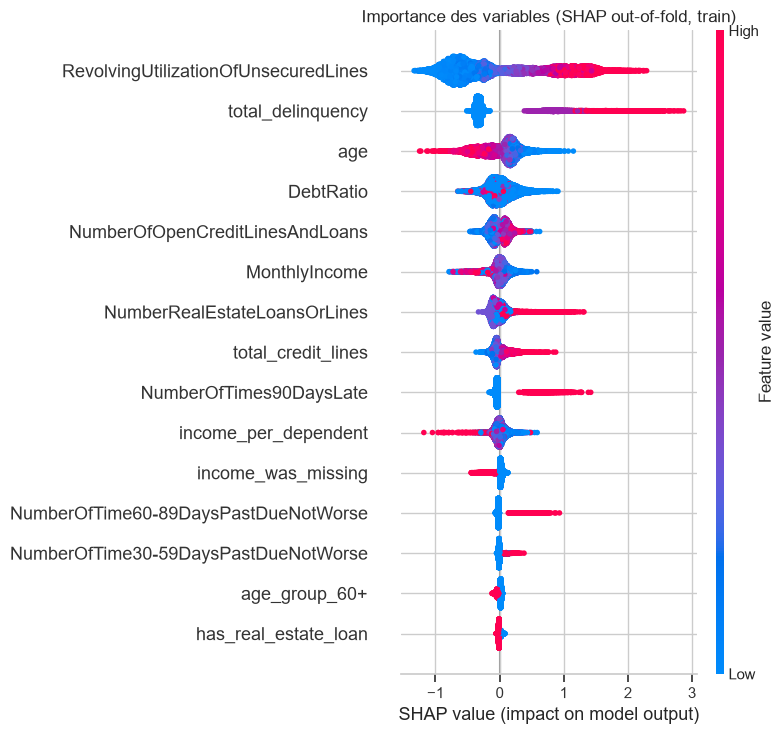

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_train), size=20000, replace=False)

shap.summary_plot(sv_oof[sample_idx], X_display.iloc[sample_idx], max_display=15, show=False)
plt.title("Importance des variables (SHAP out-of-fold, train)")
plt.tight_layout()
plt.show()

In [6]:
# Importance moyenne |SHAP| et sens de l'effet (corrélation de Spearman entre la valeur et le SHAP)
importance = pd.Series(np.abs(sv_oof).mean(axis=0), index=feature_names).sort_values(ascending=False)
direction = pd.Series(
    {f: X_display[f].corr(pd.Series(sv_oof[:, j], index=X_display.index), method="spearman")
     for j, f in enumerate(feature_names)}
)
importance_table = pd.DataFrame({
    "mean_abs_shap": importance,
    "part_%": 100 * importance / importance.sum(),
    "corr_valeur_vs_shap": direction[importance.index],
}).round(3)
importance_table.head(10)

,mean_abs_shap,part_%,corr_valeur_vs_shap
RevolvingUtilizationOfUnsecuredLines,0.694,29.979,0.900
total_delinquency,0.509,21.974,0.698
age,0.238,10.269,-0.926
DebtRatio,0.150,6.484,0.460
NumberOfOpenCreditLinesAndLoans,0.106,4.597,0.705
MonthlyIncome,0.099,4.266,-0.632
NumberRealEstateLoansOrLines,0.095,4.103,-0.019
total_credit_lines,0.086,3.726,0.747
NumberOfTimes90DaysLate,0.082,3.527,0.392
income_per_dependent,0.060,2.602,-0.366


### 1.2 Explication de décisions individuelles

Un client **typique** de chacune des quatre catégories, choisi de façon non biaisée : celui dont la
probabilité out-of-fold est la **médiane** de la catégorie (ni un cas extrême, ni un cas
soigneusement choisi pour raconter une belle histoire).

- **Vrai positif (TP)** : mauvais payeur correctement refusé (bien classé).
- **Vrai négatif (TN)** : bon client correctement accepté (bien classé).
- **Faux positif (FP)** : bon client refusé à tort (mal classé).
- **Faux négatif (FN)** : mauvais payeur accepté à tort (mal classé) — l'erreur la plus coûteuse.

Dans chaque graphique, les barres rouges poussent vers "défaut" et les bleues vers "pas de
défaut" ; `E[f(X)]` est la valeur de base et `f(x)` le log-odds final du client (au-dessus du
seuil de 0.57 en probabilité → refusé).

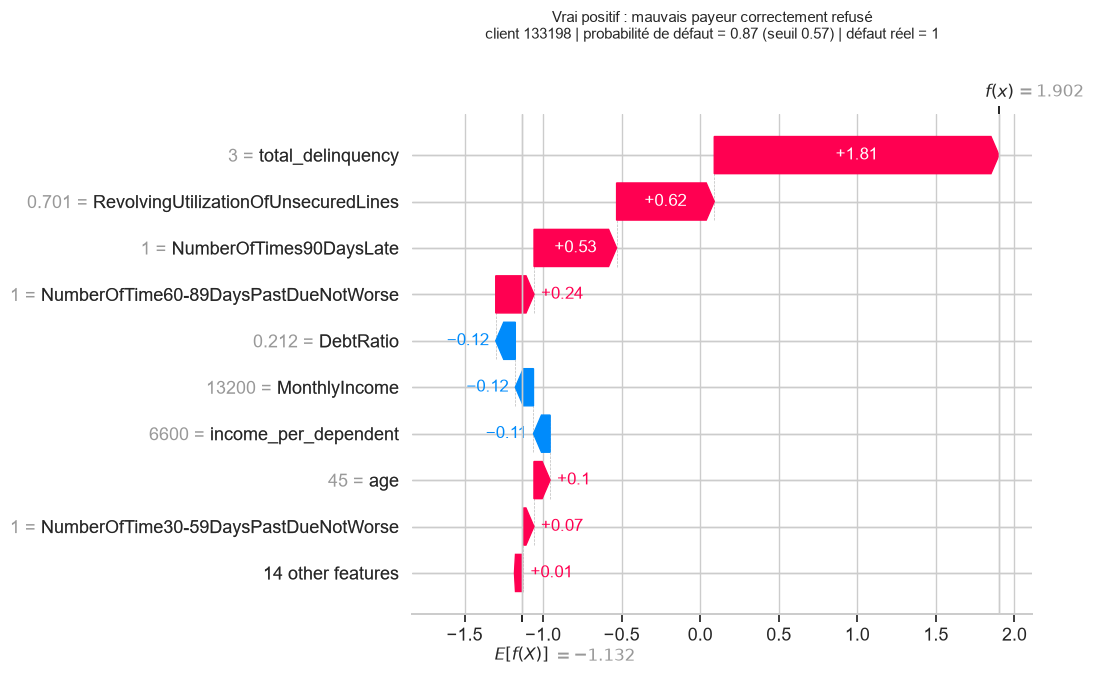

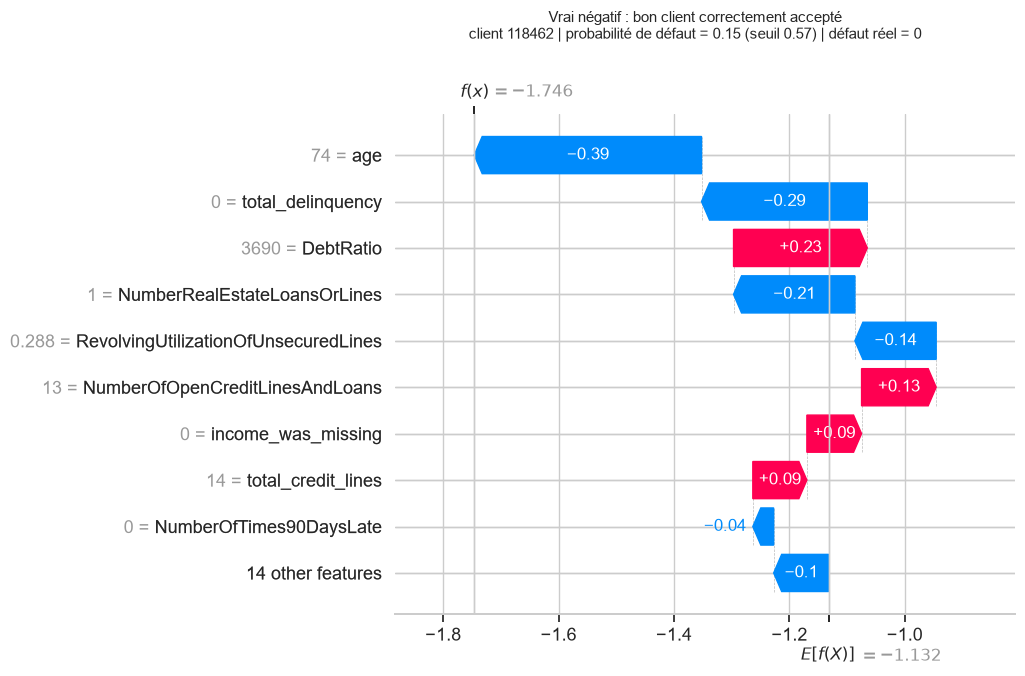

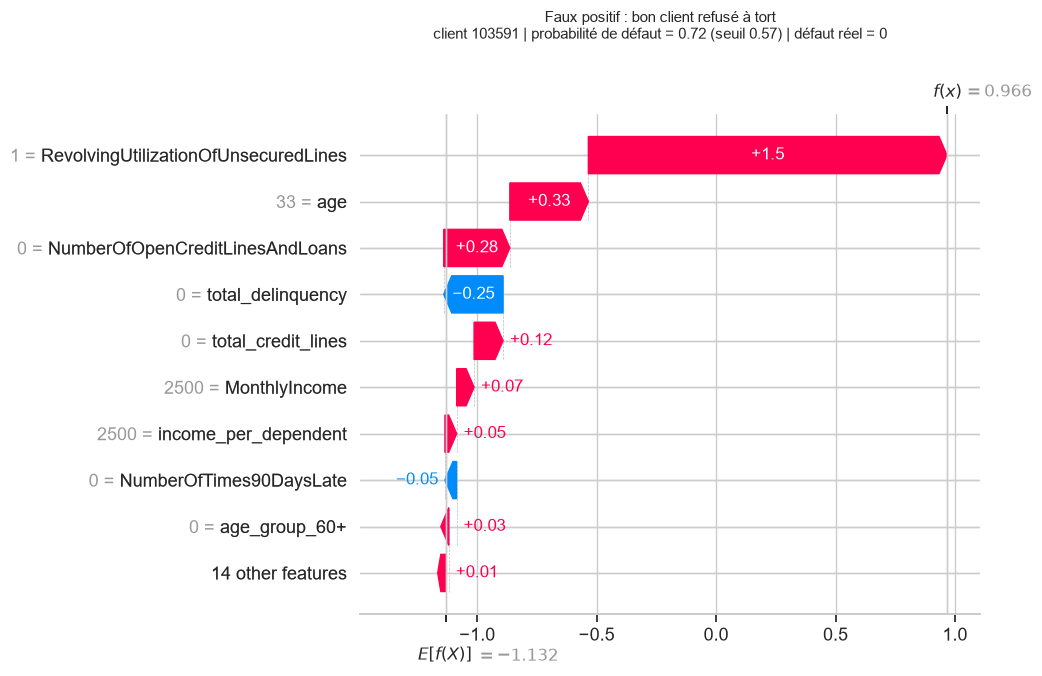

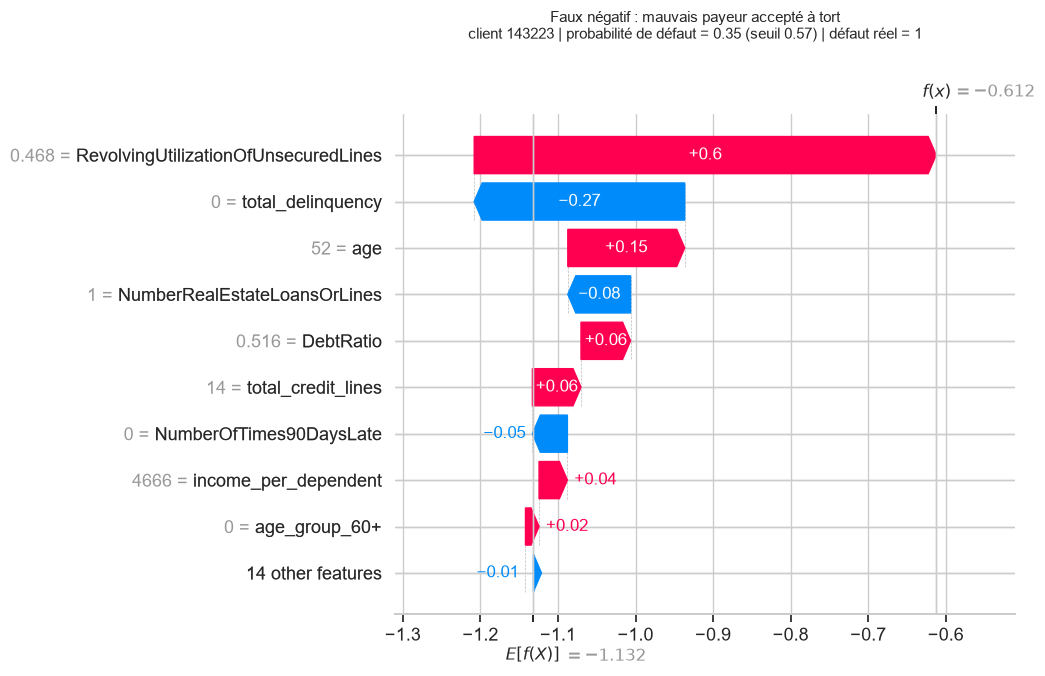

In [7]:
pred_oof = (proba_oof >= THRESHOLD).astype(int)
is_default = y_train.values == 1
category = pd.Series(
    np.select(
        [is_default & (pred_oof == 1), is_default & (pred_oof == 0), ~is_default & (pred_oof == 1)],
        ["TP", "FN", "FP"],
        default="TN",
    ),
    index=X_train.index,
)
proba_s = pd.Series(proba_oof, index=X_train.index)

def typical_client(cat):
    """Client de la catégorie dont la probabilité out-of-fold est la médiane de la catégorie."""
    ordered = proba_s[category == cat].sort_values().index
    return ordered[len(ordered) // 2]

titles = {
    "TP": "Vrai positif : mauvais payeur correctement refusé",
    "TN": "Vrai négatif : bon client correctement accepté",
    "FP": "Faux positif : bon client refusé à tort",
    "FN": "Faux négatif : mauvais payeur accepté à tort",
}

for cat in ["TP", "TN", "FP", "FN"]:
    client_id = typical_client(cat)
    pos = X_train.index.get_loc(client_id)
    explanation = shap.Explanation(
        values=sv_oof[pos],
        base_values=base_oof[pos],
        data=X_display.iloc[pos].values,
        feature_names=feature_names,
    )
    shap.plots.waterfall(explanation, max_display=10, show=False)
    plt.gcf().suptitle(
        f"{titles[cat]}\nclient {client_id} | probabilité de défaut = {proba_oof[pos]:.2f} "
        f"(seuil {THRESHOLD}) | défaut réel = {y_train.iloc[pos]}",
        fontsize=11, y=1.04,
    )
    plt.show()

### 1.3 Les 5 variables qui pèsent le plus dans les décisions

Classement par importance moyenne (moyenne des |SHAP|, out-of-fold). Le sens de l'effet vient de
la corrélation de Spearman entre la valeur de la variable et son SHAP (tableau ci-dessus).

| Rang | Variable | Part de l'importance | Sens de l'effet | Conforme à l'intuition métier ? |
|---|---|---|---|---|
| 1 | `RevolvingUtilizationOfUnsecuredLines` | 30,0 % | plus l'utilisation est élevée, plus le risque monte (+0,90) | **Oui** : un client qui a épuisé ses lignes de crédit renouvelables est sous tension de trésorerie. |
| 2 | `total_delinquency` | 22,0 % | 0 retard : effet négatif net ; dès 1 retard, l'effet devient positif et croît | **Oui** : le comportement passé est le meilleur prédicteur du comportement futur. |
| 3 | `age` | 10,3 % | plus le client est âgé, plus le risque baisse (-0,93) | **Oui** : stabilité professionnelle et financière qui augmente avec l'âge. |
| 4 | `DebtRatio` | 6,5 % | le risque augmente avec le ratio (+0,46) | **Sens oui, poids plus faible qu'attendu** : on l'attendrait en tête d'un score de crédit. |
| 5 | `NumberOfOpenCreditLinesAndLoans` | 4,6 % | le risque augmente avec le nombre de lignes (+0,71) | **Plausible** (exposition plus large au crédit), mais effet modeste. |

Les deux premières variables cumulent 52 % de l'importance, les cinq premières 73 % : le modèle
repose surtout sur **l'utilisation du crédit et l'historique de retards**, ce que l'EDA laissait
prévoir.

**Trois observations à retenir (et à pouvoir défendre)** :

- **Le feature engineering de la phase 2 est validé** : `total_delinquency` (2e) domine chacun des
  trois compteurs bruts dont elle est la somme. Le plus fort d'entre eux, `NumberOfTimes90DaysLate`,
  n'arrive qu'en 9e position alors qu'il était 2e en corrélation avec la cible dans l'EDA : ce
  n'est pas qu'il ne porte pas d'information, c'est qu'elle est déjà captée par le total (ces
  trois variables étaient corrélées à 0,98-0,99).
- **`DebtRatio` pèse moins que prévu**. Hypothèse (non testée ici) : cette variable est peu
  fiable dans ce dataset (valeurs aberrantes cappées au 99e percentile, ~20 % de revenus
  manquants sur lesquels le ratio repose).
- **Deux effets contre-intuitifs** : (1) `income_was_missing = 1` pousse vers "pas de défaut"
  (SHAP négatif), à l'inverse de l'hypothèse posée en phase 2 (revenu non déclaré = signal de
  risque) ; on ne sait pas pourquoi, c'est une corrélation à ne pas ériger en règle. (2) L'effet
  du nombre de prêts immobiliers est **non linéaire** : en avoir beaucoup augmente le risque, alors
  qu'en avoir au moins un le réduit légèrement (`has_real_estate_loan`).

*Rappel* : SHAP décrit ce que **le modèle** utilise, pas des relations de cause à effet.


## 2. Analyse des erreurs (train, out-of-fold)

On reprend les prédictions out-of-fold au seuil de 0.57 et on compare les quatre groupes
(TP, FN, FP, TN) pour voir si les erreurs ont des points communs. Toutes les valeurs sont en
unités d'origine (après nettoyage de la phase 2).

In [8]:
group_order = ["TP", "FN", "FP", "TN"]
group_labels = {
    "TP": "TP (défaut détecté)",
    "FN": "FN (défaut manqué)",
    "FP": "FP (bon client refusé)",
    "TN": "TN (bon client accepté)",
}

analysis = X_display.copy()
analysis["y"] = y_train
analysis["proba"] = proba_oof
analysis["category"] = category
analysis["any_delinquency"] = (analysis["total_delinquency"] > 0).astype(int)

counts = category.value_counts().reindex(group_order)
pd.DataFrame({
    "n": counts.values,
    "% du train": (100 * counts / len(category)).round(2).values,
}, index=[group_labels[c] for c in group_order])

,n,% du train
TP (défaut détecté),5634,4.70
FN (défaut manqué),2387,1.99
FP (bon client refusé),15973,13.31
TN (bon client accepté),96006,80.00


In [9]:
# Médiane des variables continues par groupe
medians = analysis.groupby("category")[continuous_cols].median().T[group_order]
medians.columns = [group_labels[c] for c in group_order]
medians.round(2)

,TP (défaut détecté),FN (défaut manqué),FP (bon client refusé),TN (bon client accepté)
RevolvingUtilizationOfUnsecuredLines,0.96,0.34,0.85,0.09
age,44.00,49.00,45.00,54.00
DebtRatio,0.44,0.41,0.43,0.35
MonthlyIncome,5000.00,5390.00,5100.00,5390.00
NumberOfOpenCreditLinesAndLoans,6.00,8.00,7.00,8.00
NumberOfTime30-59DaysPastDueNotWorse,1.00,0.00,1.00,0.00
NumberOfTimes90DaysLate,0.00,0.00,0.00,0.00
NumberRealEstateLoansOrLines,0.00,1.00,1.00,1.00
NumberOfTime60-89DaysPastDueNotWorse,0.00,0.00,0.00,0.00
NumberOfDependents,0.00,0.00,0.00,0.00


In [10]:
# Part (%) de clients ayant chaque indicateur binaire, par groupe
binary_display_cols = (
    feature_info["binary_cols"]
    + [c for c in feature_names if c.startswith("age_group_")]
    + ["any_delinquency"]
)
shares = 100 * analysis.groupby("category")[binary_display_cols].mean().T[group_order]
shares.columns = [group_labels[c] for c in group_order]
shares.round(1)

,TP (défaut détecté),FN (défaut manqué),FP (bon client refusé),TN (bon client accepté)
has_sentinel_delinquency,2.1,0.0,0.6,0.0
income_was_missing,17.5,13.9,15.4,20.7
dependents_was_missing,1.8,1.6,1.7,2.8
debtratio_extreme,0.9,1.3,1.2,1.0
revolving_extreme,8.4,0.3,3.4,0.2
has_real_estate_loan,48.4,65.1,52.0,65.1
age_group_30-40,25.1,18.3,24.2,13.4
age_group_40-50,29.6,25.8,29.4,21.3
age_group_50-60,22.2,25.2,22.5,23.8
age_group_60+,11.8,23.3,12.7,36.8


### 2.1 Cas limites : à quelle distance du seuil se situent les erreurs ?

Pour les faux négatifs, on mesure de combien la probabilité est **en dessous** du seuil ; pour les
faux positifs, de combien elle est **au-dessus**. Un écart faible (< 0.10) signale un cas "limite"
qu'un léger changement de seuil ou de modèle aurait pu faire basculer ; un écart élevé signale
une erreur "franche" que le modèle ne voit pas du tout.

In [11]:
gap_bins = [0, 0.10, 0.20, 0.40, 1.0]
gap_labels = ["< 0.10 (cas limites)", "0.10 - 0.20", "0.20 - 0.40", "> 0.40 (loin du seuil)"]

fn_gap = THRESHOLD - analysis.loc[category == "FN", "proba"]
fp_gap = analysis.loc[category == "FP", "proba"] - THRESHOLD

gap_table = pd.DataFrame({
    "FN : défauts manqués (%)": 100 * pd.cut(fn_gap, gap_bins, labels=gap_labels, include_lowest=True)
        .value_counts(normalize=True).sort_index(),
    "FP : bons clients refusés (%)": 100 * pd.cut(fp_gap, gap_bins, labels=gap_labels, include_lowest=True)
        .value_counts(normalize=True).sort_index(),
})
gap_table.round(1)

,FN : défauts manqués (%),FP : bons clients refusés (%)
proba,,
< 0.10 (cas limites),26.2,35.2
0.10 - 0.20,20.5,25.4
0.20 - 0.40,32.6,39.2
> 0.40 (loin du seuil),20.7,0.2


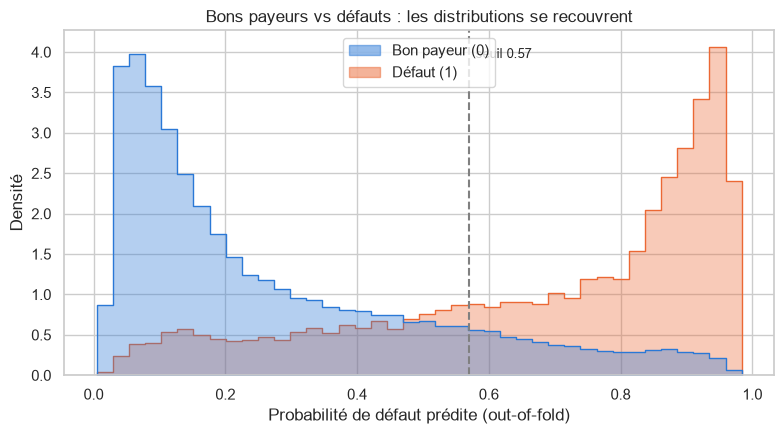

In [12]:
# Distribution des probabilités out-of-fold selon la vraie classe : zone de recouvrement
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(
    data=analysis, x="proba", hue="y", palette={0: BLUE, 1: ORANGE},
    stat="density", common_norm=False, bins=40, element="step", fill=True, alpha=0.35, ax=ax,
)
ax.axvline(THRESHOLD, color="gray", ls="--", lw=1.5)
ax.text(THRESHOLD + 0.01, ax.get_ylim()[1] * 0.92, f"seuil {THRESHOLD}", fontsize=9)
ax.set_xlabel("Probabilité de défaut prédite (out-of-fold)")
ax.set_ylabel("Densité")
ax.set_title("Bons payeurs vs défauts : les distributions se recouvrent")
# Légende explicite (couleur <-> classe) plutôt que de dépendre de l'ordre interne de seaborn
ax.legend(
    handles=[Patch(color=BLUE, alpha=0.5, label="Bon payeur (0)"), Patch(color=ORANGE, alpha=0.5, label="Défaut (1)")],
    loc="upper center",
)
plt.tight_layout()
plt.show()

In [13]:
# Contribution SHAP moyenne par groupe : quelles variables expliquent que le modèle se trompe ?
shap_by_group = (
    pd.DataFrame(sv_oof, columns=feature_names, index=X_train.index)
    .groupby(category).mean().T[group_order]
)
shap_by_group.columns = [group_labels[c] for c in group_order]
shap_by_group.loc[importance.index[:8]].round(2)

,TP (défaut détecté),FN (défaut manqué),FP (bon client refusé),TN (bon client accepté)
RevolvingUtilizationOfUnsecuredLines,0.92,0.24,0.85,-0.21
total_delinquency,1.26,-0.05,0.82,-0.23
age,0.11,0.06,0.13,-0.03
DebtRatio,0.07,0.04,0.09,0.00
NumberOfOpenCreditLinesAndLoans,0.02,0.00,0.03,-0.01
MonthlyIncome,0.03,-0.00,0.03,-0.01
NumberRealEstateLoansOrLines,0.03,0.02,0.04,-0.01
total_credit_lines,0.02,0.02,0.03,-0.00


### 2.2 Synthèse : limites structurelles du modèle

**Faux positifs (15 973 clients, 13,3 % du train) : ils ressemblent aux vrais défauts.**
70 % ont au moins un retard passé (contre 85 % des défauts détectés et 8 % des bons clients
acceptés), leur utilisation médiane du crédit est de 0.85 (défauts détectés : 0.96 ; bons clients
acceptés : 0.09), et leur âge et revenu médians sont quasi identiques à ceux des défauts
détectés (45 vs 44 ans, 5 100 vs 5 000). Le modèle les lit "correctement" (contributions SHAP du
même sens que pour les vrais défauts : +0,85 vs +0,92 pour l'utilisation, +0,82 vs +1,26 pour les
retards) : ces clients ont un profil à risque mais n'ont pas fait défaut dans les 2 ans. Avec ces
variables, on ne peut pas les distinguer. 35 % d'entre eux sont à moins de 0.10 au-dessus du seuil.

**Faux négatifs (2 387 clients, 2,0 % du train) : ils ressemblent aux bons clients.**
79,5 % n'ont aucun retard passé (contre 15 % des défauts détectés), leur utilisation médiane est de
0.34 (entre 0.09 et 0.96), 65 % ont un prêt immobilier (exactement comme les bons clients
acceptés : 65,1 %), et ils sont plus âgés (23 % ont 60 ans et plus, contre 12 % des défauts
détectés). Pour eux, la contribution SHAP de `total_delinquency` est nulle (-0,05) alors qu'elle
est de +1,26 pour les défauts détectés : le signal principal du modèle est absent.
**Cas limites** : 26 % des faux négatifs sont à moins de 0.10 sous le seuil et 47 % à moins de
0.20 ; à l'inverse, 21 % sont à plus de 0.40 sous le seuil (probabilité < 0.17), des défauts que
le modèle ne voit pas du tout.

**Ce que cela révèle sur les limites structurelles :**

1. **Le modèle repose sur deux signaux** (utilisation du crédit et retards passés : 52 % de
   l'importance). Un mauvais payeur sans retard passé et à utilisation modérée est presque
   indétectable : c'est le cas de ~80 % des défauts manqués.
2. **Des informations manquent** (pistes, non testées ici) : le dataset est une photo à un instant
   donné, sans information sur le prêt demandé (montant, durée, objet), la situation
   professionnelle (type de contrat, ancienneté), l'épargne ou le patrimoine, l'évolution dans le
   temps (tendance de l'utilisation, retards récents ou anciens) ni les événements de vie (perte
   d'emploi, maladie, divorce) qui provoquent souvent le défaut.
3. **Les deux classes se recouvrent fortement** entre 0.2 et 0.8 (graphique ci-dessus). Déplacer le
   seuil ne fait qu'échanger des faux négatifs contre des faux positifs : en phase 3, gagner ~10
   points de recall (seuil 0.43) coûtait ~10 500 bons clients refusés en plus. Tous les modèles
   plafonnent d'ailleurs à un AUC-PR de 0.38-0.40 : la limite vient de l'information contenue dans
   les variables, pas de l'algorithme.
4. **La qualité des variables de capacité de remboursement est limitée** : ~20 % de revenus
   manquants et un `DebtRatio` aux valeurs aberrantes cappées (hypothèse pour expliquer le poids
   modeste de `DebtRatio` et `MonthlyIncome`).

*Précision* : ces chiffres portent sur les prédictions out-of-fold du train, au seuil choisi sur
ces mêmes prédictions ; ils décrivent le comportement du modèle, sans valeur de preuve causale.


## 3. Évaluation finale sur le test

### 3.1 Reconstruction du pipeline de la phase 2 à partir du train

Les statistiques apprises en phase 2 (médianes, mode, seuils de capping p99) n'avaient pas été
sauvegardées ; on les **réapprend sur le train brut uniquement** (`fit_cleaning_params`, module
`src/preprocessing.py`). Avant de toucher au test, on **valide** cette reconstruction : rejouée
sur le train, elle doit redonner exactement les features sauvegardées en phase 2
(`X_train_processed.csv`).

In [14]:
train_raw = pd.read_csv("../data/processed/train.csv", index_col="id")

cleaning_params = fit_cleaning_params(train_raw)
print("Paramètres appris sur le train :")
for k, v in cleaning_params.items():
    print(f"  {k}: {v}")

# Validation : le pipeline reconstruit reproduit les features de la phase 2 (sur le train)
X_check = apply_cleaning(train_raw, cleaning_params, scaler, feature_names, continuous_cols)
max_diff = (X_check - X_train[feature_names]).abs().max().max()
assert X_check.index.equals(X_train.index) and max_diff < 1e-9, "Pipeline reconstruit différent de la phase 2"
print(f"\nPipeline validé sur le train : écart max avec X_train_processed.csv = {max_diff:.1e}")

Paramètres appris sur le train :
  late_medians: {'NumberOfTime30-59DaysPastDueNotWorse': 0.0, 'NumberOfTime60-89DaysPastDueNotWorse': 0.0, 'NumberOfTimes90DaysLate': 0.0}
  income_median: 5390.0
  dependents_mode: 0.0
  age_median: 52.0
  debtratio_cap: 4977.0
  revolving_cap: 1.0944386634299974

Pipeline validé sur le train : écart max avec X_train_processed.csv = 1.4e-14


### 3.2 Application au test (première et unique utilisation)

Le test est chargé ici pour la première fois. On lui applique le pipeline avec les paramètres du
train (`apply_cleaning` : uniquement des `transform`, aucun fit), puis le modèle final entraîné sur
tout le train et le seuil de 0.57. **Aucune décision (modèle, hyperparamètres, seuil) ne sera
modifiée à partir de ces résultats.**

In [15]:
test_raw = pd.read_csv("../data/processed/test.csv", index_col="id")
y_test = test_raw[TARGET]

# Mêmes transformations que le train, avec les paramètres appris sur le train
X_test = apply_cleaning(test_raw, cleaning_params, scaler, feature_names, continuous_cols)

assert X_test.isna().sum().sum() == 0, "Il reste des NaN dans le test"
assert list(X_test.columns) == feature_names
print(f"Test : {X_test.shape} | défauts : {y_test.mean():.2%} (train : {y_train.mean():.2%})")

# Prédiction avec le modèle final (entraîné sur tout le train) et le seuil retenu en phase 3
proba_test = final_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= THRESHOLD).astype(int)

test_metrics = {
    "average_precision": average_precision_score(y_test, proba_test),
    "roc_auc": roc_auc_score(y_test, proba_test),
    "recall": recall_score(y_test, pred_test),
    "precision": precision_score(y_test, pred_test),
}
for m, v in test_metrics.items():
    print(f"  {m}: {v:.3f}")

Test : (30000, 23) | défauts : 6.68% (train : 6.68%)


  average_precision: 0.406
  roc_auc: 0.869
  recall: 0.711
  precision: 0.258


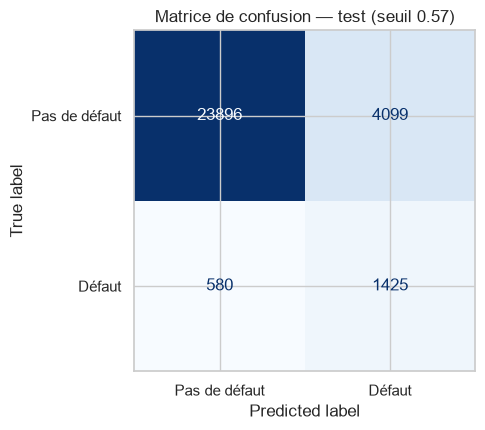

Mauvais payeurs détectés : 1425 / 2005 (71.1%)
Bons clients refusés     : 4099 / 27995 (14.6% des bons clients)
Part de clients refusés  : 18.4%


In [16]:
cm = confusion_matrix(y_test, pred_test)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Pas de défaut", "Défaut"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Matrice de confusion — test (seuil {THRESHOLD})")
plt.tight_layout()
plt.show()

print(f"Mauvais payeurs détectés : {tp} / {tp + fn} ({tp / (tp + fn):.1%})")
print(f"Bons clients refusés     : {fp} / {fp + tn} ({fp / (fp + tn):.1%} des bons clients)")
print(f"Part de clients refusés  : {(tp + fp) / len(y_test):.1%}")

### 3.3 Comparaison avec la validation croisée (phase 3)

Deux repères pour juger l'écart entre CV et test :
- l'**écart-type entre folds** de la CV ;
- un **intervalle de confiance bootstrap à 95 %** sur le test (le test est un échantillon fini :
  ses métriques ont leur propre incertitude, surtout pour recall/precision qui reposent sur ~2 000
  défauts). Si la moyenne CV tombe dans cet intervalle, l'écart est compatible avec le simple
  bruit d'échantillonnage.

Un test **nettement moins bon** que la CV (hors intervalle) signalerait de l'overfitting.

In [17]:
# Intervalle de confiance bootstrap (500 rééchantillonnages du test avec remise)
rng = np.random.default_rng(RANDOM_STATE)
n_test = len(y_test)
y_arr = y_test.values
boot = {m: [] for m in test_metrics}
for _ in range(500):
    idx = rng.integers(0, n_test, n_test)
    yt, yp, pr = y_arr[idx], proba_test[idx], pred_test[idx]
    boot["average_precision"].append(average_precision_score(yt, yp))
    boot["roc_auc"].append(roc_auc_score(yt, yp))
    boot["recall"].append(recall_score(yt, pr))
    boot["precision"].append(precision_score(yt, pr))
ci = {m: np.percentile(v, [2.5, 97.5]) for m, v in boot.items()}

labels = {
    "average_precision": "AUC-PR",
    "roc_auc": "AUC-ROC",
    "recall": "Recall (défaut)",
    "precision": "Precision (défaut)",
}
rows = []
for m, label in labels.items():
    cv_mean, cv_std = cv_metrics[m]
    lo, hi = ci[m]
    rows.append({
        "métrique": label,
        "CV (moy +/- std)": f"{cv_mean:.3f} (+/- {cv_std:.3f})",
        "test": round(test_metrics[m], 3),
        "IC 95 % test": f"[{lo:.3f}, {hi:.3f}]",
        "test - CV": round(test_metrics[m] - cv_mean, 3),
        "écart en std CV": round((test_metrics[m] - cv_mean) / cv_std, 1),
        "CV dans l'IC du test": "oui" if lo <= cv_mean <= hi else "NON",
    })
comparison = pd.DataFrame(rows).set_index("métrique")
display(comparison)

consistent = all(r["CV dans l'IC du test"] == "oui" for r in rows)
print("\nVerdict automatique :",
      "cohérent (la moyenne CV est dans l'IC 95 % du test pour les 4 métriques)" if consistent
      else "écart à examiner (au moins une métrique CV hors de l'IC 95 % du test)")

,CV (moy +/- std),test,IC 95 % test,test - CV,écart en std CV,CV dans l'IC du test
métrique,,,,,,
AUC-PR,0.403 (+/- 0.004),0.406,"[0.383, 0.430]",0.002,0.5,oui
AUC-ROC,0.864 (+/- 0.003),0.869,"[0.861, 0.878]",0.005,1.5,oui
Recall (défaut),0.702 (+/- 0.008),0.711,"[0.691, 0.730]",0.008,1.0,oui
Precision (défaut),0.261 (+/- 0.003),0.258,"[0.246, 0.268]",-0.003,-1.0,oui



Verdict automatique : cohérent (la moyenne CV est dans l'IC 95 % du test pour les 4 métriques)


## 4. Conclusion du projet

### Conclusion :
